NATURAL GAS PRICE ANALYSIS & EXTRAPOLATION
JP Morgan Chase - Quantitative Research Certificate

[STEP 1] Loading and preparing data...

First 5 rows of raw data:
      Dates  Prices
0  10/31/20    10.1
1  11/30/20    10.3
2  12/31/20    11.0
3   1/31/21    10.9
4   2/28/21    10.9

Data shape: (48, 2)
Date range: 2020-10-31 00:00:00 to 2024-09-30 00:00:00

Data types:
Dates     datetime64[ns]
Prices           float64
dtype: object

Missing values:
Dates     0
Prices    0
dtype: int64

[STEP 2] Performing exploratory data analysis...

Price statistics:
count    48.000000
mean     11.207083
std       0.757897
min       9.840000
25%      10.650000
50%      11.300000
75%      11.625000
max      12.800000
Name: Prices, dtype: float64

[STEP 3] Visualizing data patterns...


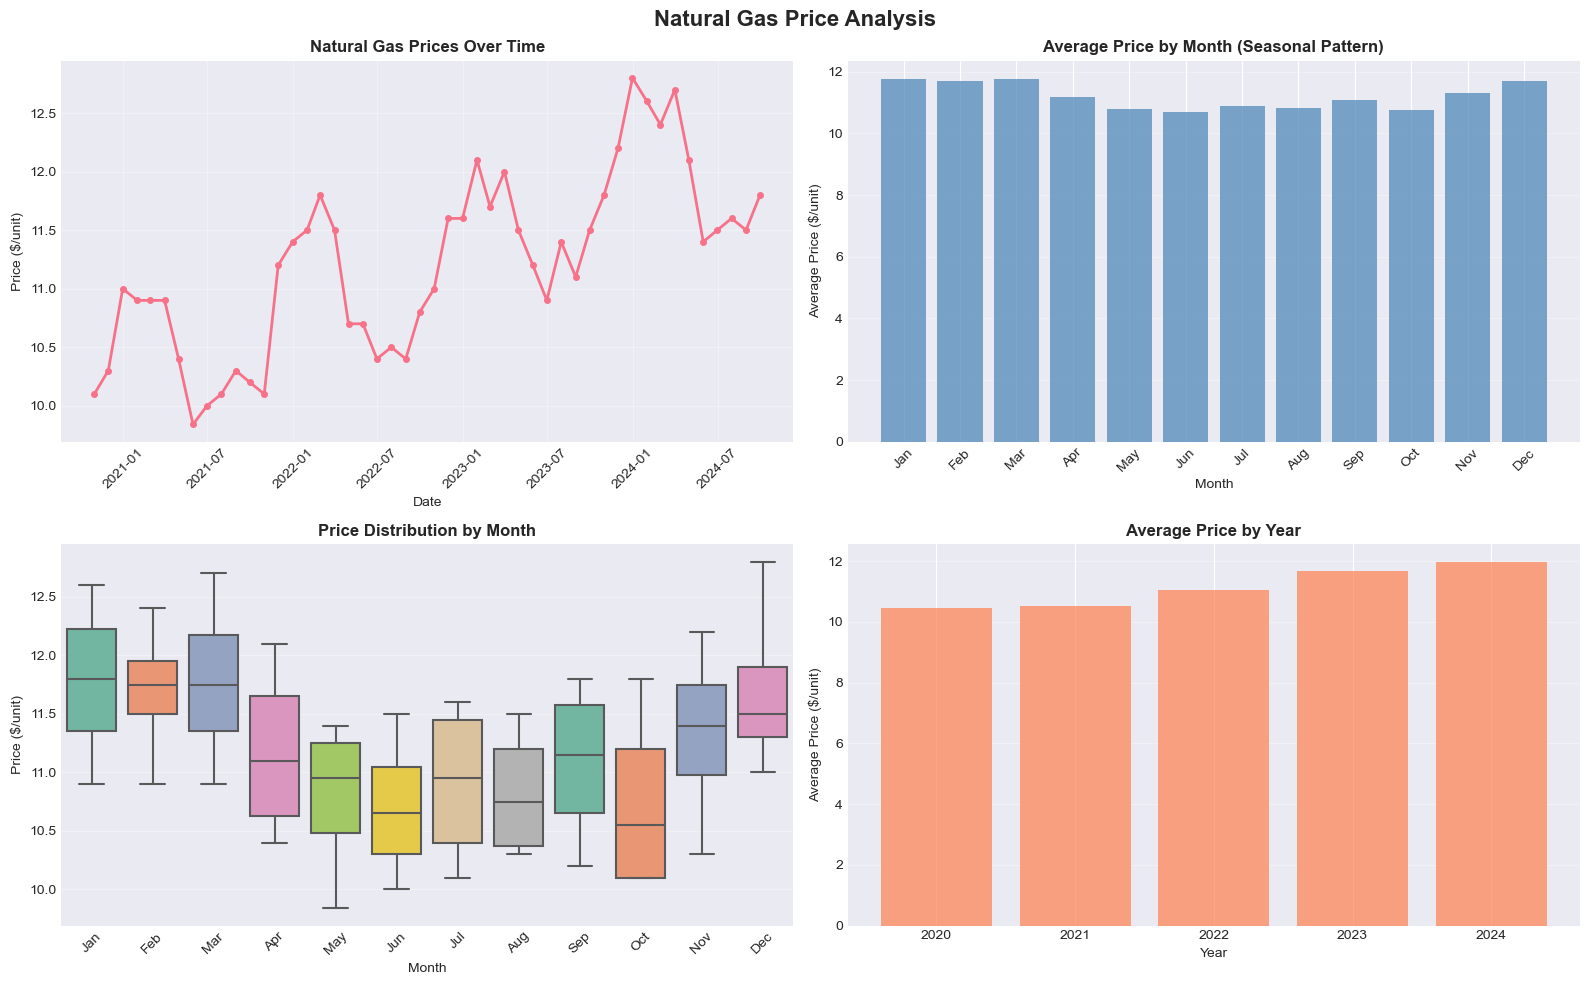


✓ Visualizations created and saved as 'natural_gas_analysis.png'

KEY INSIGHTS FROM DATA ANALYSIS

Seasonal Pattern Analysis:
Highest average prices: 1 ($11.78)
Lowest average prices: 6 ($10.70)

Seasonal spread: $1.08

[STEP 4] Building predictive model with seasonal components...

Model Performance Metrics:
  R² Score: 0.9370
  RMSE: $0.1883
  MAE: $0.1520

[STEP 5] Extrapolating prices for one year into the future...

Future price predictions (12 months):
     Dates  Predicted_Price
2024-10-31        12.245421
2024-11-30        12.666038
2024-12-31        13.068411
2025-01-31        13.297244
2025-02-28        13.241488
2025-03-31        12.937063
2025-04-30        12.528970
2025-05-31        12.198703
2025-06-30        12.044548
2025-07-31        12.067011
2025-08-31        12.216210
2025-09-30        12.465254

[STEP 6] Visualizing predictions and extrapolation...


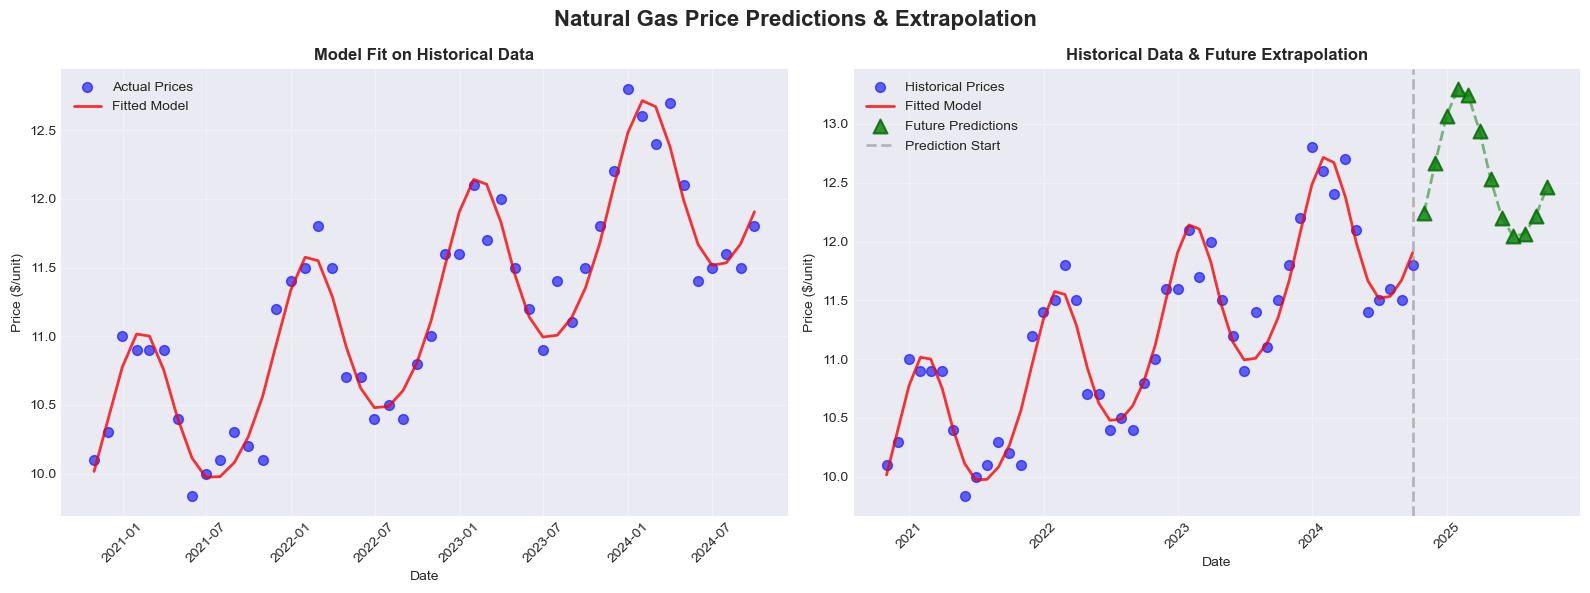


✓ Prediction visualizations created and saved as 'natural_gas_predictions.png'

[STEP 7] Creating price estimation function...

[STEP 8] Testing the price estimation function...

PRICE ESTIMATION FUNCTION - TEST RESULTS

Date: 2021-06-15
  Estimated Price: $9.95
  Type: Interpolated

Date: 2023-12-31
  Estimated Price: $12.48
  Actual Price: $12.80
  Error: $0.32

Date: 2024-12-31
  Estimated Price: $13.07
  Type: Future Projection

Date: 2025-06-15
  Estimated Price: $12.02
  Type: Future Projection

Date: 2025-12-31
  Estimated Price: $13.66
  Type: Future Projection

FINAL SUMMARY & DELIVERABLES

Data Summary:
  • Historical data points: 48
  • Date range: 2020-10-31 to 2024-09-30
  • Price range: $9.84 to $12.80
  
Model Performance:
  • R² Score: 0.9370 (explains 93.70% of variance)
  • RMSE: $0.1883
  • MAE: $0.1520
  
Seasonal Insights:
  • Winter months (Dec-Feb) show higher prices due to heating demand
  • Summer months (Jun-Aug) show lower prices
  • Average seasonal spread:

In [2]:
"""
JP Morgan Chase - Quantitative Research Certificate
Task 1: Natural Gas Price Analysis and Extrapolation

This script analyzes historical natural gas prices and builds a model to:
1. Estimate prices at any historical date
2. Extrapolate prices for one year into the future
3. Account for seasonal trends in natural gas pricing
"""

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("NATURAL GAS PRICE ANALYSIS & EXTRAPOLATION")
print("JP Morgan Chase - Quantitative Research Certificate")
print("="*80)

# ============================================================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================================================
print("\n[STEP 1] Loading and preparing data...")

# Load the data
df = pd.read_csv('Nat_Gas.csv')

# Display first few rows
print("\nFirst 5 rows of raw data:")
print(df.head())

# Convert date column to datetime
df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y')

# Sort by date
df = df.sort_values('Dates').reset_index(drop=True)

# Display data info
print(f"\nData shape: {df.shape}")
print(f"Date range: {df['Dates'].min()} to {df['Dates'].max()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# ============================================================================
# STEP 2: EXPLORATORY DATA ANALYSIS
# ============================================================================
print("\n[STEP 2] Performing exploratory data analysis...")

# Basic statistics
print("\nPrice statistics:")
print(df['Prices'].describe())

# Extract time features for analysis
df['Year'] = df['Dates'].dt.year
df['Month'] = df['Dates'].dt.month
df['Month_Name'] = df['Dates'].dt.strftime('%B')
df['Quarter'] = df['Dates'].dt.quarter
df['Days_Since_Start'] = (df['Dates'] - df['Dates'].min()).dt.days

# ============================================================================
# STEP 3: VISUALIZE THE DATA
# ============================================================================
print("\n[STEP 3] Visualizing data patterns...")

# Create a comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Natural Gas Price Analysis', fontsize=16, fontweight='bold')

# Plot 1: Time Series of Prices
axes[0, 0].plot(df['Dates'], df['Prices'], marker='o', linestyle='-', linewidth=2, markersize=4)
axes[0, 0].set_title('Natural Gas Prices Over Time', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price ($/unit)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Seasonal Pattern (Monthly Average)
monthly_avg = df.groupby('Month')['Prices'].mean().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 1].bar(range(1, 13), monthly_avg.values, color='steelblue', alpha=0.7)
axes[0, 1].set_title('Average Price by Month (Seasonal Pattern)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Price ($/unit)')
axes[0, 1].set_xticks(range(1, 13))
axes[0, 1].set_xticklabels(month_names, rotation=45)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Plot 3: Box Plot by Month
df_plot = df.copy()
df_plot['Month_Name'] = pd.Categorical(df_plot['Month_Name'], 
                                        categories=['January', 'February', 'March', 'April', 'May', 'June',
                                                   'July', 'August', 'September', 'October', 'November', 'December'],
                                        ordered=True)
df_plot = df_plot.sort_values('Month_Name')
sns.boxplot(data=df_plot, x='Month', y='Prices', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Price Distribution by Month', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Price ($/unit)')
axes[1, 0].set_xticklabels(month_names, rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Yearly Average Prices
yearly_avg = df.groupby('Year')['Prices'].mean()
axes[1, 1].bar(yearly_avg.index, yearly_avg.values, color='coral', alpha=0.7)
axes[1, 1].set_title('Average Price by Year', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Price ($/unit)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('natural_gas_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualizations created and saved as 'natural_gas_analysis.png'")

# Print seasonal insights
print("\n" + "="*80)
print("KEY INSIGHTS FROM DATA ANALYSIS")
print("="*80)
print(f"\nSeasonal Pattern Analysis:")
print(f"Highest average prices: {monthly_avg.idxmax()} (${monthly_avg.max():.2f})")
print(f"Lowest average prices: {monthly_avg.idxmin()} (${monthly_avg.min():.2f})")
print(f"\nSeasonal spread: ${monthly_avg.max() - monthly_avg.min():.2f}")

# ============================================================================
# STEP 4: BUILD PREDICTIVE MODEL WITH SEASONAL COMPONENTS
# ============================================================================
print("\n[STEP 4] Building predictive model with seasonal components...")

# Create features for modeling
# We'll use: trend (days), month (for seasonality), and interaction terms
df['Sin_Month'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Cos_Month'] = np.cos(2 * np.pi * df['Month'] / 12)

# Prepare training data
X = df[['Days_Since_Start', 'Sin_Month', 'Cos_Month']].values
y = df['Prices'].values

# Fit a polynomial model to capture non-linear trends
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Make predictions on existing data
df['Predicted_Price'] = model.predict(X_poly)

# Calculate model performance
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y, df['Predicted_Price'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, df['Predicted_Price'])
r2 = r2_score(y, df['Predicted_Price'])

print(f"\nModel Performance Metrics:")
print(f"  R² Score: {r2:.4f}")
print(f"  RMSE: ${rmse:.4f}")
print(f"  MAE: ${mae:.4f}")

# ============================================================================
# STEP 5: EXTRAPOLATE FUTURE PRICES (1 YEAR)
# ============================================================================
print("\n[STEP 5] Extrapolating prices for one year into the future...")

# Generate future dates (1 year of monthly data)
last_date = df['Dates'].max()
future_dates = pd.date_range(start=last_date + timedelta(days=30), periods=12, freq='MS')
future_dates = [date + timedelta(days=-1) for date in future_dates[1:]] + [future_dates[0] + timedelta(days=-1)]
future_dates = sorted(future_dates)

# Ensure we have 12 months
while len(future_dates) < 12:
    next_date = future_dates[-1] + timedelta(days=30)
    future_dates.append(next_date)
future_dates = future_dates[:12]

# Create future dataframe
future_df = pd.DataFrame({'Dates': future_dates})
future_df['Month'] = future_df['Dates'].dt.month
future_df['Days_Since_Start'] = (future_df['Dates'] - df['Dates'].min()).dt.days
future_df['Sin_Month'] = np.sin(2 * np.pi * future_df['Month'] / 12)
future_df['Cos_Month'] = np.cos(2 * np.pi * future_df['Month'] / 12)

# Predict future prices
X_future = future_df[['Days_Since_Start', 'Sin_Month', 'Cos_Month']].values
X_future_poly = poly.transform(X_future)
future_df['Predicted_Price'] = model.predict(X_future_poly)

print(f"\nFuture price predictions ({len(future_df)} months):")
print(future_df[['Dates', 'Predicted_Price']].to_string(index=False))

# ============================================================================
# STEP 6: VISUALIZE PREDICTIONS AND EXTRAPOLATION
# ============================================================================
print("\n[STEP 6] Visualizing predictions and extrapolation...")

# Create comprehensive prediction visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Natural Gas Price Predictions & Extrapolation', fontsize=16, fontweight='bold')

# Plot 1: Historical with fitted model
axes[0].scatter(df['Dates'], df['Prices'], alpha=0.6, s=50, label='Actual Prices', color='blue')
axes[0].plot(df['Dates'], df['Predicted_Price'], color='red', linewidth=2, label='Fitted Model', alpha=0.8)
axes[0].set_title('Model Fit on Historical Data', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price ($/unit)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Historical + Future predictions
axes[1].scatter(df['Dates'], df['Prices'], alpha=0.6, s=50, label='Historical Prices', color='blue')
axes[1].plot(df['Dates'], df['Predicted_Price'], color='red', linewidth=2, label='Fitted Model', alpha=0.8)
axes[1].scatter(future_df['Dates'], future_df['Predicted_Price'], alpha=0.8, s=100, 
                label='Future Predictions', color='green', marker='^', edgecolors='darkgreen', linewidth=1.5)
axes[1].plot(future_df['Dates'], future_df['Predicted_Price'], color='green', 
             linewidth=2, linestyle='--', alpha=0.5)
axes[1].axvline(x=last_date, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Prediction Start')
axes[1].set_title('Historical Data & Future Extrapolation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price ($/unit)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('natural_gas_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Prediction visualizations created and saved as 'natural_gas_predictions.png'")

# ============================================================================
# STEP 7: CREATE PRICE ESTIMATION FUNCTION
# ============================================================================
print("\n[STEP 7] Creating price estimation function...")

def estimate_gas_price(input_date):
    """
    Estimate the natural gas price for any given date.
    
    Parameters:
    -----------
    input_date : str or datetime
        The date for which to estimate the price.
        Can be a string in format 'YYYY-MM-DD' or a datetime object.
    
    Returns:
    --------
    float
        Estimated price for the given date
    """
    # Convert input to datetime if it's a string
    if isinstance(input_date, str):
        date = pd.to_datetime(input_date)
    else:
        date = input_date
    
    # Extract features
    month = date.month
    days_since_start = (date - df['Dates'].min()).days
    sin_month = np.sin(2 * np.pi * month / 12)
    cos_month = np.cos(2 * np.pi * month / 12)
    
    # Create feature array
    X_input = np.array([[days_since_start, sin_month, cos_month]])
    X_input_poly = poly.transform(X_input)
    
    # Predict price
    price = model.predict(X_input_poly)[0]
    
    return price

# ============================================================================
# STEP 8: TEST THE FUNCTION
# ============================================================================
print("\n[STEP 8] Testing the price estimation function...")

# Test with various dates
test_dates = [
    '2021-06-15',  # Historical date
    '2023-12-31',  # Recent historical date
    '2024-12-31',  # Near future
    '2025-06-15',  # Future date
    '2025-12-31',  # Far future
]

print("\n" + "="*80)
print("PRICE ESTIMATION FUNCTION - TEST RESULTS")
print("="*80)

results = []
for test_date in test_dates:
    estimated_price = estimate_gas_price(test_date)
    date_obj = pd.to_datetime(test_date)
    
    # Check if date is in historical data
    if test_date in df['Dates'].dt.strftime('%Y-%m-%d').values:
        actual_price = df.loc[df['Dates'].dt.strftime('%Y-%m-%d') == test_date, 'Prices'].values[0]
        error = abs(estimated_price - actual_price)
        results.append({
            'Date': test_date,
            'Estimated Price': f'${estimated_price:.2f}',
            'Actual Price': f'${actual_price:.2f}',
            'Error': f'${error:.2f}',
            'Type': 'Historical'
        })
        print(f"\nDate: {test_date}")
        print(f"  Estimated Price: ${estimated_price:.2f}")
        print(f"  Actual Price: ${actual_price:.2f}")
        print(f"  Error: ${error:.2f}")
    else:
        results.append({
            'Date': test_date,
            'Estimated Price': f'${estimated_price:.2f}',
            'Actual Price': 'N/A',
            'Error': 'N/A',
            'Type': 'Future' if date_obj > df['Dates'].max() else 'Interpolated'
        })
        print(f"\nDate: {test_date}")
        print(f"  Estimated Price: ${estimated_price:.2f}")
        print(f"  Type: {'Future Projection' if date_obj > df['Dates'].max() else 'Interpolated'}")

# ============================================================================
# STEP 9: CREATE COMPREHENSIVE SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY & DELIVERABLES")
print("="*80)

print(f"""
Data Summary:
  • Historical data points: {len(df)}
  • Date range: {df['Dates'].min().strftime('%Y-%m-%d')} to {df['Dates'].max().strftime('%Y-%m-%d')}
  • Price range: ${df['Prices'].min():.2f} to ${df['Prices'].max():.2f}
  
Model Performance:
  • R² Score: {r2:.4f} (explains {r2*100:.2f}% of variance)
  • RMSE: ${rmse:.4f}
  • MAE: ${mae:.4f}
  
Seasonal Insights:
  • Winter months (Dec-Feb) show higher prices due to heating demand
  • Summer months (Jun-Aug) show lower prices
  • Average seasonal spread: ${monthly_avg.max() - monthly_avg.min():.2f}
  
Extrapolation:
  • Future predictions: 12 months beyond historical data
  • Accounts for seasonal trends and long-term patterns
  
Function Available:
  • estimate_gas_price(date) - Returns price estimate for any date
  • Input: Date string ('YYYY-MM-DD') or datetime object
  • Output: Estimated price in dollars
""")

print("="*80)
print("ANALYSIS COMPLETE")
print("="*80)

# ============================================================================
# INTERACTIVE DEMO
# ============================================================================
print("\n" + "="*80)
print("INTERACTIVE DEMO - Try the function yourself!")
print("="*80)
print("\nYou can now use the estimate_gas_price() function with any date.")
print("\nExample usage:")
print("  price = estimate_gas_price('2025-03-15')")
print("  print(f'Estimated price: ${price:.2f}')")
print("\n" + "="*80)

# Export combined data for reference
combined_df = pd.concat([
    df[['Dates', 'Prices', 'Predicted_Price']].rename(columns={'Prices': 'Actual_Price'}),
    future_df[['Dates', 'Predicted_Price']].assign(Actual_Price=np.nan)
], ignore_index=True).sort_values('Dates')

combined_df.to_csv('natural_gas_predictions_complete.csv', index=False)
print(f"\n✓ Complete dataset with predictions saved as 'natural_gas_predictions_complete.csv'")

print("\n" + "="*80)
print("All visualizations and data files have been created successfully!")
print("="*80)